In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Lasso, LinearRegression
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import scipy.stats as stats

In [2]:
# read in historical constituents data
df_stocks = pd.read_csv('sp500.csv')
#convert date columns to pandas dates
df_stocks['start'] = pd.to_datetime(df_stocks['start'], errors='coerce')
df_stocks['ending'] = pd.to_datetime(df_stocks['ending'], errors='coerce')
df_stocks['date'] = pd.to_datetime(df_stocks['date'], errors='coerce')

In [3]:
df_stocks.head()

,date,permno,comnam,ticker,start,ending,ret,prc,shrout,gsector,GICS Sector
0,2000-01-03,14891,UNOCAL CORP,UCL,1957-03-01,2005-08-10,-0.016760,33.0000,242418.0,10.0,Energy
1,2000-01-03,48725,UNION PACIFIC CORP,UNP,1969-07-16,2024-12-31,-0.014306,43.0625,248568.0,20.0,Industrials
2,2000-01-03,24272,ASHLAND INC,ASH,1989-08-03,2008-11-13,-0.028463,32.0000,71291.0,15.0,Materials
3,2000-01-03,22680,MILACRON INC,MZ,1954-04-20,2000-06-28,0.004065,15.4375,37013.0,20.0,Industrials
4,2000-01-03,28222,AIR PRODUCTS & CHEMICALS INC,APD,1985-04-11,2024-12-31,-0.022346,32.8125,229305.0,15.0,Materials


In [4]:
# read in index returns data
df_index = pd.read_csv('spreturns.csv')
# convert date column to pandas dates
df_index['date'] = pd.to_datetime(df_index['date'], errors='coerce')

In [5]:
df_index.head()

,date,sp500_ret
0,2000-01-03,-0.009373
1,2000-01-04,-0.038439
2,2000-01-05,0.000852
3,2000-01-06,-0.002845
4,2000-01-07,0.032193


In [6]:
# calculate todays closing market cap
df_stocks['mkt_cap'] = df_stocks['prc'].abs() * df_stocks['shrout']

# sort chronologically by stock so the shift works correctly
df_stocks = df_stocks.sort_values(by=['permno', 'date'])

# shift the market cap down by 1 row per stock to get previous day market cap
df_stocks['mkt_cap_prev'] = df_stocks.groupby('permno')['mkt_cap'].shift(1)

In [7]:
# function to verify for a specific day that the reconstructed returns from the constituents matches the true index return
def verify_day(target_date):
    # filter for the specific date
    day_data = df_stocks[df_stocks['date'] == target_date].copy()
    
    # drop rows where previous day's market cap doesn't exist (e.g., their first day of trading)
    day_data = day_data.dropna(subset=['mkt_cap_prev'])
    
    if day_data.empty:
        return None
    
    # calculate weights based on yesterdays market cap
    total_mkt_cap = day_data['mkt_cap_prev'].sum()
    day_data['weight'] = day_data['mkt_cap_prev'] / total_mkt_cap
    
    # portfolio return = sum of weights x returns
    replicated_ret = (day_data['weight'] * day_data['ret']).sum()
    
    # get the actual return
    actual_ret = df_index[df_index['date'] == target_date]['sp500_ret'].values[0]
    
    # return statistics for the day
    return {
        'date': target_date,
        'replicated_ret': replicated_ret,
        'actual_ret': actual_ret,
        'diff': replicated_ret - actual_ret,
        'num_stocks': len(day_data)
    }

In [8]:
# test function for a single day
test_date = pd.Timestamp('2015-01-05')
result = verify_day(test_date)

print(f"Verification for {test_date.date()}")
print(f"Replicated Return: {result['replicated_ret']:.6f}")
print(f"Actual Return:     {result['actual_ret']:.6f}")
print(f"Difference:        {result['diff']:.6f}")
print(f"Stocks Included:   {result['num_stocks']}")

Verification for 2015-01-05
Replicated Return: -0.018112
Actual Return:     -0.018112
Difference:        0.000000
Stocks Included:   502


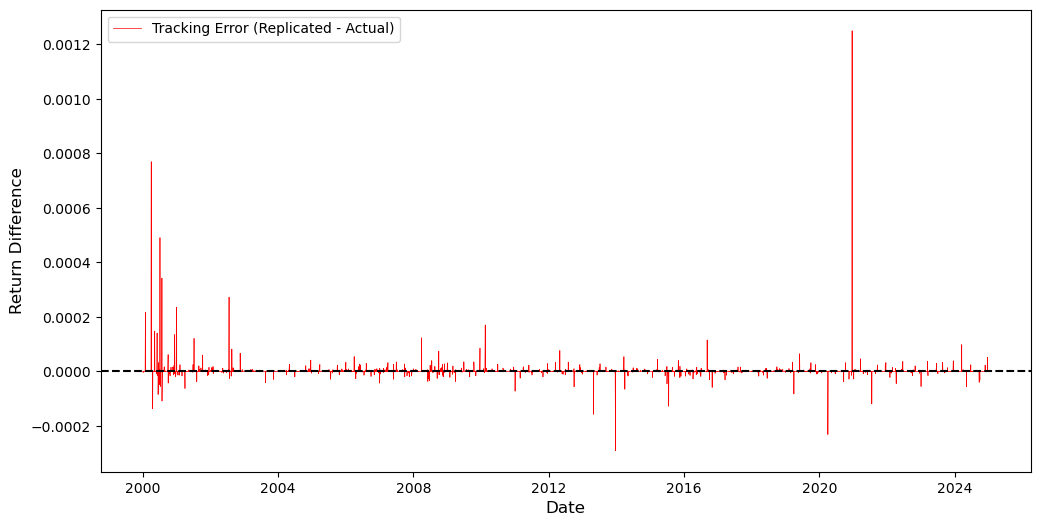

Mean Absolute Error: 0.000002


In [9]:
# loop through the whole dataset to verify

# results storage
results_list = []

# loop through unique dates
unique_dates = df_stocks['date'].unique()

for date in unique_dates:
    res = verify_day(date)
    if res:
        results_list.append(res)

# convert to pandas df to access columns
df_verify = pd.DataFrame(results_list)

plt.figure(figsize=(12, 6))
plt.plot(df_verify['date'], df_verify['diff'], label='Tracking Error (Replicated - Actual)', color='red', linewidth=0.5)
plt.axhline(0, color='black', linestyle='--')
plt.ylabel('Return Difference', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend()
plt.show()

print(f"Mean Absolute Error: {df_verify['diff'].abs().mean():.6f}")